### 06 — Cost-Sensitive Risk Optimization & Decision Threshold Design

#### Objective

This notebook moves beyond predictive accuracy and evaluates optimal decision thresholds under asymmetric financial cost assumptions.

We address:

1. What is the optimal probability threshold for bankruptcy classification?
2. How does this threshold change across forecast horizons?
3. How sensitive is threshold selection to economic cost asymmetry?

---

#### Why Cost-Sensitive Analysis?

In corporate risk systems:

- Missing a bankrupt firm (False Negative) is highly costly.
- Incorrectly flagging a healthy firm (False Positive) has operational cost.

Default classification threshold (0.5) assumes equal cost — which is unrealistic.

Therefore, we optimize decision thresholds by minimizing:

Expected Loss = FN × Cost_FN + FP × Cost_FP

---

#### Cost Assumptions (Base Case)

- Cost_FN = 10
- Cost_FP = 1

This reflects:

- Bankruptcy miss is 10× more costly than false alarm.
- Reflects conservative risk management approach.

We evaluate:

- Optimal threshold per horizon.
- Minimum achievable expected loss.
- Threshold sensitivity to varying cost ratios.

In [1]:
from scipy.io import arff
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier


def cost_analysis(file_path, cost_fn=10, cost_fp=1):
    
    data, meta = arff.loadarff(file_path)
    df = pd.DataFrame(data)

    df["class"] = df["class"].apply(lambda x: int(x.decode("utf-8")))

    X = df.drop(columns=["class"])
    y = df["class"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    model = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        colsample_bytree=0.8,
        scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:, 1]

    thresholds = np.linspace(0.01, 0.99, 100)
    losses = []

    for t in thresholds:
        preds = (probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
        loss = fn * cost_fn + fp * cost_fp
        losses.append(loss)

    losses = np.array(losses)

    optimal_idx = np.argmin(losses)
    optimal_threshold = thresholds[optimal_idx]
    min_loss = losses[optimal_idx]

    return optimal_threshold, min_loss

In [2]:
horizons = ["1year.arff", "2year.arff", "3year.arff", "4year.arff", "5year.arff"]

results = []

for file in horizons:
    opt_t, min_loss = cost_analysis(f"../data/raw/{file}", cost_fn=10, cost_fp=1)
    results.append((file, opt_t, min_loss))

cost_df = pd.DataFrame(results, columns=["Horizon", "Optimal_Threshold", "Min_Loss"])

cost_df

,Horizon,Optimal_Threshold,Min_Loss
0,1year.arff,0.277273,140
1,2year.arff,0.386162,334
2,3year.arff,0.227778,396
3,4year.arff,0.356465,437
4,5year.arff,0.099091,210


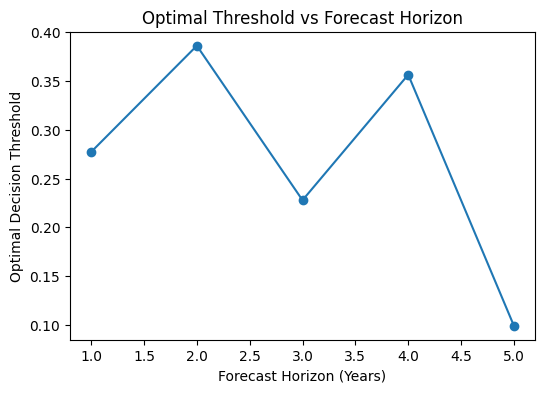

In [9]:
import matplotlib.pyplot as plt
# Assuming cost_df already exists
cost_df["Year"] = cost_df["Horizon"].str.extract(r'(\d)').astype(int)

plt.figure(figsize=(6,4))
plt.plot(cost_df["Year"], cost_df["Optimal_Threshold"], marker='o')
plt.xlabel("Forecast Horizon (Years)")
plt.ylabel("Optimal Decision Threshold")
plt.title("Optimal Threshold vs Forecast Horizon")

plt.savefig("../results/threshold_vs_horizon.png", dpi=300, bbox_inches="tight")
plt.show()

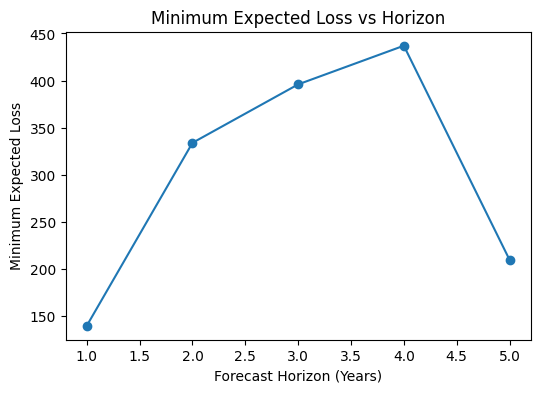

In [7]:
plt.figure(figsize=(6,4))
plt.plot(cost_df["Year"], cost_df["Min_Loss"], marker='o')
plt.xlabel("Forecast Horizon (Years)")
plt.ylabel("Minimum Expected Loss")
plt.title("Minimum Expected Loss vs Horizon")

plt.savefig("../results/min_loss_vs_horizon.png", dpi=300, bbox_inches="tight")
plt.show()

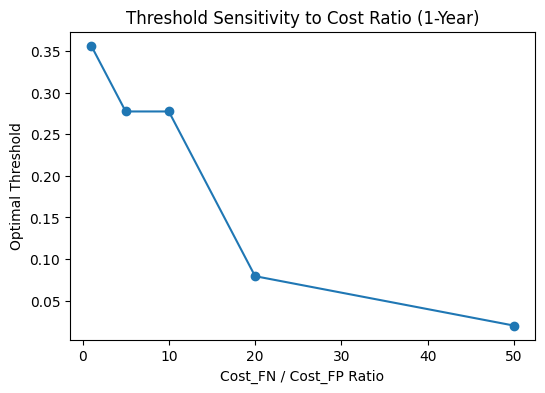

In [10]:
def threshold_vs_cost(file_path, cost_ratios):
    thresholds = []
    
    for ratio in cost_ratios:
        opt_t, _ = cost_analysis(file_path, cost_fn=ratio, cost_fp=1)
        thresholds.append(opt_t)
    
    return thresholds


cost_ratios = [1, 5, 10, 20, 50]

thresholds = threshold_vs_cost("../data/raw/1year.arff", cost_ratios)

plt.figure(figsize=(6,4))
plt.plot(cost_ratios, thresholds, marker='o')
plt.xlabel("Cost_FN / Cost_FP Ratio")
plt.ylabel("Optimal Threshold")
plt.title("Threshold Sensitivity to Cost Ratio (1-Year)")

plt.savefig("../results/threshold_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

### 📌 Observations & Decision-Theoretic Insights

#### 1️⃣ Optimal Threshold ≠ 0.5

Optimal thresholds ranged approximately:

| Horizon | Optimal Threshold |
|----------|------------------|
| 1-Year | ~0.28 |
| 2-Year | ~0.39 |
| 3-Year | ~0.23 |
| 4-Year | ~0.36 |
| 5-Year | ~0.10 |

Default 0.5 threshold would result in higher expected loss.

---

#### 2️⃣ Horizon-Dependent Risk Policy

- 5-year horizon requires aggressive threshold (~0.10).
- Medium-term horizons require more conservative cutoffs.
- Risk tolerance varies structurally across time regimes.

---

#### 3️⃣ Minimum Expected Loss Pattern

Loss increases from 1 → 4 years,
then decreases at 5-year.

This mirrors earlier temporal ROC behavior.

---

#### 4️⃣ Threshold Sensitivity to Cost Ratio

As Cost_FN / Cost_FP increases:

- Optimal threshold decreases smoothly.
- System becomes more conservative.
- Recall increases to avoid costly bankruptcy misses.

This demonstrates economic coherence of the model.

---

#### 5️⃣ Structural Takeaway

Bankruptcy prediction is not just a classification problem.

It is:

- A policy design problem.
- A cost-sensitive optimization problem.
- A deployment-aligned decision system.

Decision thresholds must reflect institutional risk appetite and economic consequences.